# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание. Нейронные сети

### Общая информация

Дата выдачи: 24.03.2026

Мягкий дедлайн: 14.04.2026 23:59

Жесткий дедлайн: 19.04.2026 23:59

### О задании

В этой работе две независимые части:

- Часть 1. Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца - 4 балла.

- Часть 2. CNN-классификация звуков на датасете UrbanSound8K - 6 баллов.

### Оценивание

Максимально допустимая оценка за работу - 10 баллов. 4 балла за SPINN и 6 баллов за CNN.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке. Оценка также может быть снижена за плохо читаемый код и плохо оформленные диаграммы/таблицы. Изменять проверочные ячейки и пороги `assert` запрещено.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Про вычислительные ресурсы

Задание рассчитано на выполнение в бесплатном Google Colab или Kaggle Notebook, если реализация сделана разумно.

- Используйте GPU экономно: черновую отладку, проверку кода и подготовку пайплайна лучше сначала выполнять на CPU, а GPU подключать уже для обучения и финальных экспериментов. Это поможет избежать лишних проблем с памятью и не тратить ресурсы впустую.
- Для SPINN обучение должно занимать умеренное время; если одна конфигурация обучается слишком долго, стоит проверить размер модели, число коллокационных точек и эффективность реализации.
- Для UrbanSound8K рекомендуется предвычислять спектрограммы и сохранять их на диск. Без этого эксперименты часто упираются в CPU-препроцессинг, а не в обучение модели.
- Для подбора гиперпараметров разумно сначала работать на одном фиксированном dev-split, а полный 10-fold cross-validation запускать только для финальной модели.
- При обучении свёрточных сетей может помочь `torch.backends.cudnn.benchmark = True`.

### Формат сдачи

Задания сдаются через систему Anytask. Необходимо прислать ноутбук с выполненным заданием; к ноутбуку прикрепите два файла с весами лучших моделей для каждой из двух задач: `best_spinn_model.pth` и `best_cnn_model.pth`. Сам ноутбук называйте в формате `homework-practice-04-dl-Username.ipynb`, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку, исходя из набора выполненных задач и достигнутого качества, и укажите её ниже.

Оценка: 9.0






In [1]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import librosa
import librosa.display
from IPython.display import Audio

In [2]:
random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Часть 1. SPINN для 3D-уравнения Гельмгольца (4 балла)


### Разбалловка

Для удобства разбалловка задания представлена в таблице ниже. В первой части основное внимание уделяется корректной реализации SPINN-архитектуры, организации обучения и анализу результатов.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 1.1 Реализация separable-архитектуры | **2,0** | Реализация класса `BaseSPINN`: три body-сети, корректная separable-сборка решения на решётке и на произвольных точках, согласованность с `BaseModel` |
| 1.2 Обучение и качество | **1,5** | Модель сходится, обучение организовано корректно, результат воспроизводим, достигнуто разумное качество на тестовой сетке |
| 1.3 Анализ экспериментов | **0,5** | Краткий разбор выбранной конфигурации и наблюдений по качеству и скорости


### Что такое PINN

**Physics-Informed Neural Networks (PINNs)** - это нейросетевые модели, которые используют для обучения не только данные, но и структуру самой физической задачи.

Идея состоит в том, что модель должна не просто приближать неизвестную функцию, а строить решение, которое согласовано с заданным дифференциальным уравнением и граничными условиями.

В отличие от стандартной постановки supervised learning, где у нас есть множество пар "вход-ответ", в PINN функция потерь обычно включает две части:

- PDE loss - это невязка дифференциального уравнения внутри области;
- BC loss - это ошибка на границе области, где известны граничные условия.

Благодаря этому PINN можно применять даже в ситуациях, когда наблюдений мало, но сама структура задачи хорошо известна.

Физика - ммм, уже испугались?)

> На деле, глубоко разбираться в физике здесь не требуется. Вся постановка задачи первой части - уравнение, точное решение, функция источника и граничные условия - уже реализована в `BaseModel`.

Для выполнения задания достаточно понимать следующее:

- есть неизвестная функция $u(x, y, z)$, которую нужно приблизить нейросетью;
- внутри области решение должно удовлетворять дифференциальному уравнению (PDE loss);
- на границе куба решение должно обращаться в ноль (BC loss);
- точное решение нам известно, поэтому мы можем измерять ошибку модели после обучения.

**Ваша задача - реализовать архитектуру SPINN**, а не выводить физические формулы с нуля.

> *SPINN - чего?* 😧

### Что такое SPINN

**SPINN (Separable Physics-Informed Neural Network)** - это архитектурная модификация PINN для многомерных задач.  

[Статья: *Separable Physics-Informed Neural Networks*, NeurIPS 2023](https://arxiv.org/abs/2306.15969)

В обычном PINN одна большая сеть получает на вход сразу точку $(x, y, z)$ и предсказывает значение функции $u(x, y, z)$.

В SPINN идея другая: вместо одной общей сети используются несколько небольших сетей - по одной на каждую координату.  

Для нашей 3D-задачи это означает:

- первая сеть обрабатывает только $x$;
- вторая сеть обрабатывает только $y$;
- третья сеть обрабатывает только $z$.

Каждая из этих сетей возвращает вектор длины `rank`, а итоговое решение собирается через CP-подобное объединение:

$$
u[i, j, k] = \sum_{r=1}^{\text{rank}} f_x[i, r] \cdot f_y[j, r] \cdot f_z[k, r].
$$

Интуитивно это похоже на CP-декомпозицию ([Canonical Polyadic decomposition](https://en.wikipedia.org/wiki/Tensor_rank_decomposition#:~:text=clarification%20needed%5D-,Canonical%20polyadic%20decomposition%20(CPD),-is%20a%20variant)), где трёхмерный тензор представляется как сумма тензоров ранга 1:

$$
\hat{u} = \sum_{r=1}^{R} \mathbf{f}_r^{(x)} \otimes \mathbf{f}_r^{(y)} \otimes \mathbf{f}_r^{(z)}.
$$

Главная идея здесь в том, что на tensor-product grid можно отдельно обработать оси, а затем собрать итоговый тензор решения. Именно поэтому SPINN особенно удобен для многомерных PDE-задач, где pointwise-подход быстро становится вычислительно дорогим.

> В этой домашней работе мы используем **учебную реализацию ключевой идеи SPINN**: separable body-сети + CP-merge. Вам не нужно воспроизводить все технические детали статьи; важно корректно реализовать архитектуру и получить рабочее решение.
>
> Но если вам захочется погрузиться в задачу максимально - препятствовать не будем, скорее замолвим за вас словечко в [LAMBDA](https://cs.hse.ru/iai/lambda/).

### Уравнение Гельмгольца

В задаче рассматривается 3D-уравнение Гельмгольца:

$$
\nabla^2 u + k^2 u = q(x,y,z), \quad (x,y,z) \in [-1,1]^3, \quad u\big|_{\text{граница}} = 0.
$$

Здесь:

- $u(x,y,z)$ - неизвестная функция;
- $k$ - волновое число;
- $q(x,y,z)$ - правая часть (источник);
- на границе области заданы нулевые граничные условия Дирихле.

Для тестирования используется точное решение:

$$
u(x,y,z) = \sin(\pi x)\sin(\pi y)\sin(\pi z).
$$

На всех шести гранях куба $\Omega = [-1,1]^3$ задаются нулевые граничные условия:

$$
u(x,y,z) = 0, \quad (x,y,z) \in \partial \Omega.
$$

### Описание задания

В этой части вам нужно:

1. реализовать три независимые body-сети —- по одной для каждой координаты;
2. получить из них separable-представление решения;
3. корректно объединить выходы через CP-merge;
4. реализовать вычисление модели на решётке и на произвольных точках;
5. обучить модель, оценить качество решения на тестовой сетке и проанализировать результаты.

Несколько вспомогательных функций для точного решения, оценки ошибки и визуализации:

In [3]:
def helmholtz3d_exact_u(a1, a2, a3, x, y, z):
    return (
        torch.sin(a1 * torch.pi * x)
        * torch.sin(a2 * torch.pi * y)
        * torch.sin(a3 * torch.pi * z)
    )


def relative_l2(u_pred, u_true):
    """Относительная L2-ошибка: ||u_pred - u_true|| / ||u_true||"""
    return torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)

А тут вспомогательные функции для визуализации и оценки: код уже готов и нужен вам как инфраструктура для экспериментов. Он помогает визуализировать решение, отслеживать динамику loss'ов, считать ошибку на тестовой сетке и пересэмплировать коллокационные точки.

In [4]:
def plot_helmholtz3d(x, y, z, u):
    x = x.detach().cpu().numpy().flatten()
    y = y.detach().cpu().numpy().flatten()
    z = z.detach().cpu().numpy().flatten()
    u = u.detach().cpu().numpy().flatten()

    u_norm = (u - u.min()) / (u.max() - u.min() + 1e-10)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        x, y, z,
        c=u_norm,
        s=1,
        cmap="seismic",
        vmin=0,
        vmax=1,
        alpha=0.75,
        edgecolors="none",
    )

    ax.set_title("U(x, y, z)", fontsize=18)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    cbar = plt.colorbar(scatter, shrink=0.8, aspect=15)
    cbar.set_label("u(x,y,z)")

    plt.tight_layout()
    plt.show()


def plot_losses(
    loss_history,
    residual_history,
    boundary_history,
    error_history,
    log_iter,
    title_prefix="",
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.semilogy(loss_history, label="Total Loss", linewidth=2)
    ax1.semilogy(residual_history, label="PDE Loss", alpha=0.7)
    ax1.semilogy(boundary_history, label="BC Loss", alpha=0.7)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss (log scale)")
    ax1.set_title(f"{title_prefix}Training Losses")

    iterations = np.arange(0, len(error_history) * log_iter, log_iter)
    ax2.semilogy(iterations, error_history, "r-", linewidth=2, label="Relative L2 Error")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Error (log scale)")
    ax2.set_title(f"{title_prefix}Relative L2 Error")

    plt.tight_layout()
    plt.show()


def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    """
    Вычисление ошибки модели на фиксированной сетке.
    """

    was_training = model.training
    model.eval()

    with torch.no_grad():
        coords = torch.stack(
            [x_grid.flatten(), y_grid.flatten(), z_grid.flatten()],
            dim=1,
        )
        u_pred = model(coords)
        error = relative_l2(u_pred, u_true.flatten())

    if was_training:
        model.train()

    return error, u_pred.reshape(x_grid.shape)


def resample_collocation_points(model, NC, domain_size=1.0):
    """
    Ресэмплирование коллокационных точек на кубической решётке.
    """

    N_per_axis = int(round(NC ** (1 / 3)))

    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)

    xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")

    xc = xx.flatten().requires_grad_(True)
    yc = yy.flatten().requires_grad_(True)
    zc = zz.flatten().requires_grad_(True)

    return xc, yc, zc

Глянем на визуальзацию точного решения на тестовой сетке.

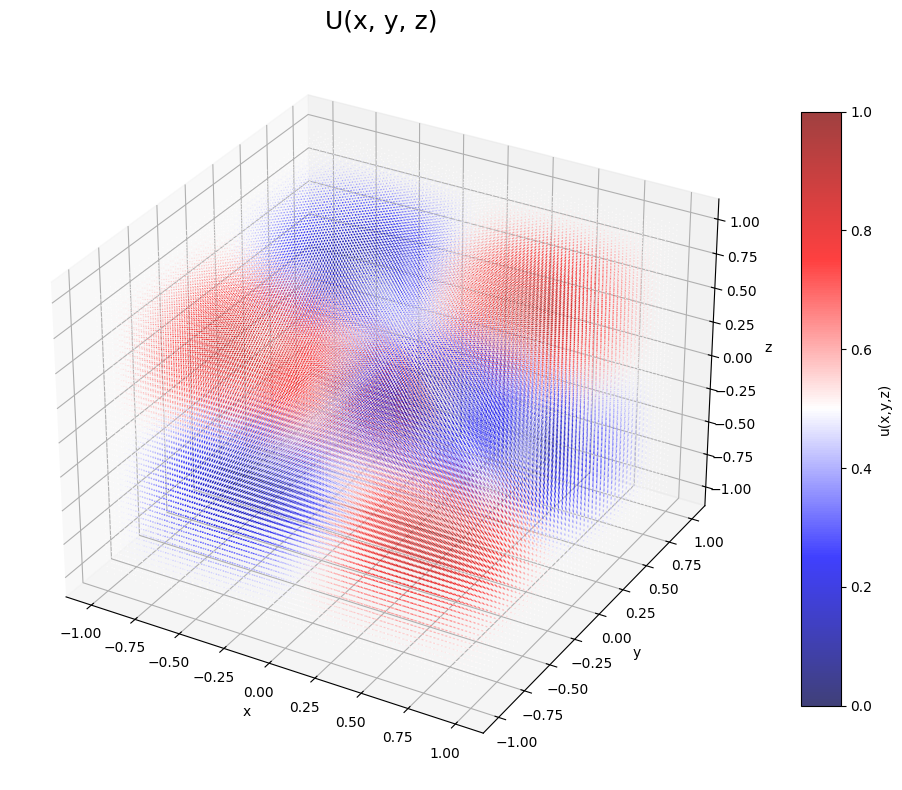

In [5]:
N_test = 50

x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing="ij")
u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

### Задание 1.1. Реализуйте SPINN-архитектуру (2 балла)

В этом пункте нужно реализовать дочерний класс от `BaseModel`, который задаёт Separable Physics-Informed Neural Network для трёхмерного уравнения Гельмгольца.

Идея остаётся той же, что и в [статье](https://arxiv.org/pdf/2306.15969): вместо одной сети, работающей сразу с тройкой координат, используется три независимые body-сети - для $x$, $y$ и $z$. Их выходы затем объединяются в separable-представление решения

$$
u(x,y,z)=\sum_{j=1}^r f_j^{(1)}(x)\,f_j^{(2)}(y)\,f_j^{(3)}(z).
$$

Базовый класс уже содержит всю постановку задачи: точное решение, правую часть уравнения, граничные условия, вычисление `PDE loss` и `BC loss`. Менять его не нужно. Ваша часть работы - архитектура.

Что именно требуется:
- собрать класс `BaseSPINN`;
- реализовать три независимые body-сети;
- определить, как из их выходов получается решение на полной решётке;
- отдельно продумать, как считать модель на произвольном наборе точек, когда координаты уже не образуют декартово произведение.

Здесь важно не просто получить рабочий код, а аккуратно разобраться в размерностях. От того, какие формы имеют выходы body-сетей, зависит и корректность `forward`, и вычисление PDE loss.

После реализации сделайте короткую sanity check-проверку:
- создайте маленькую модель;
- проверьте формы выходов body-сетей;
- убедитесь, что на решётке получается тензор формы `(Nx, Ny, Nz)`;
- отдельно проверьте вычисление на наборе произвольных точек.

In [6]:
# здесь ничего не меняем - изучаем, переиспользуем

class BaseModel(nn.Module):
    """
    Базовый класс для 3D-уравнения Гельмгольца на кубе [-1, 1]^3.

    Здесь уже реализованы:
    - точное решение и правая часть PDE;
    - граничные точки на 6 гранях куба;
    - вычисление PDE loss и BC loss.

    В этом задании предполагается, что студент реализует только
    архитектурную часть в наследнике BaseSPINN.
    """

    def __init__(
        self,
        x_min: float = -1.0,
        x_max: float = 1.0,
        y_min: float = -1.0,
        y_max: float = 1.0,
        z_min: float = -1.0,
        z_max: float = 1.0,
        k: float = 1.0,
        a1: int = 1,
        a2: int = 1,
        a3: int = 1,
        N_bc: int = 32,
        device: torch.device = None,
    ):
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N_bc = N_bc
        self.k = k
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")
        self._init_boundary_points()

    def _init_boundary_points(self):
        N = self.N_bc
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        faces = []

        for x_val in [self.x_min, self.x_max]:
            yy, zz = torch.meshgrid(lin_y, lin_z, indexing="ij")
            xx = torch.full_like(yy, x_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for y_val in [self.y_min, self.y_max]:
            xx, zz = torch.meshgrid(lin_x, lin_z, indexing="ij")
            yy = torch.full_like(xx, y_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for z_val in [self.z_min, self.z_max]:
            xx, yy = torch.meshgrid(lin_x, lin_y, indexing="ij")
            zz = torch.full_like(xx, z_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for i, coords in enumerate(faces, 1):
            self.register_buffer(f"coords_bc{i}", coords.to(self.device))
            self.register_buffer(
                f"zeros_bc{i}",
                torch.zeros(coords.shape[0], 1, device=self.device)
            )

    def reference_solution(self, x, y, z):
        """Точное решение. Используется только для оценки ошибки."""
        return (
            torch.sin(self.a1 * np.pi * x)
            * torch.sin(self.a2 * np.pi * y)
            * torch.sin(self.a3 * np.pi * z)
        )

    def function_of_source(self, x, y, z):
        """Правая часть PDE, полученная подстановкой точного решения."""
        u = self.reference_solution(x, y, z)
        lap_coef = -(self.a1 * np.pi) ** 2 - (self.a2 * np.pi) ** 2 - (self.a3 * np.pi) ** 2
        return (lap_coef + self.k**2) * u

    def get_body_outputs(self, x, y, z):
        """
        Должен быть реализован в наследнике.

        Ожидаемые формы:
        - x: (Nx,), y: (Ny,), z: (Nz,)
        - f_x: (Nx, rank), f_y: (Ny, rank), f_z: (Nz, rank)
        """
        raise NotImplementedError

    def forward(self, x, y, z):
        """
        Значения решения на полной декартовой решётке.
        """
        raise NotImplementedError

    def forward_pointwise(self, coords):
        """
        Значения решения на произвольном наборе точек coords формы (B, 3).
        """
        raise NotImplementedError

    @staticmethod
    def _body_second_deriv(f, inp):
        """
        Вторая производная по одной координате для каждого канала ранга.
        Предполагается, что f.shape == (N, rank), inp.shape == (N,).
        """
        _, rank = f.shape
        d2 = torch.zeros_like(f)

        for r in range(rank):
            d1 = torch.autograd.grad(f[:, r].sum(), inp, create_graph=True)[0]
            d2[:, r] = torch.autograd.grad(d1.sum(), inp, create_graph=True)[0]

        return d2

    def calculate_pde_loss(self, x_col, y_col, z_col):
        """
        PDE loss на коллокационной решётке.
        """
        x = x_col.clone().detach().requires_grad_(True)
        y = y_col.clone().detach().requires_grad_(True)
        z = z_col.clone().detach().requires_grad_(True)

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        f_x_d2 = self._body_second_deriv(f_x, x)
        f_y_d2 = self._body_second_deriv(f_y, y)
        f_z_d2 = self._body_second_deriv(f_z, z)

        u = self.forward(x, y, z)

        lap = (
            torch.einsum("ir,jr,kr->ijk", f_x_d2, f_y, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y_d2, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y, f_z_d2)
        )

        xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")
        q = self.function_of_source(xx, yy, zz)

        residual = lap + self.k**2 * u - q
        return self.mse(residual, torch.zeros_like(residual))

    def calculate_bc_loss(self):
        """
        MSE на шести гранях куба.
        """
        loss = torch.tensor(0.0, device=self.device)

        for i in range(1, 7):
            coords = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")
            u_bc = self.forward_pointwise(coords).unsqueeze(-1)
            loss = loss + self.mse(u_bc, zeros)

        return loss

    def calculate_loss(self, x_col, y_col, z_col):
        loss_pde = self.calculate_pde_loss(x_col, y_col, z_col)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

Теперь реализуйте класс `BaseSPINN`.

В этом пункте сигнатуры методов не даны заранее. Вам нужно самостоятельно восстановить архитектуру класса, согласовав её с тем, как устроен `BaseModel`, как вычисляется `PDE loss`, и как далее используется модель в обучении.

Вам нужно самостоятельно продумать:
- как устроена одна body-сеть;
- какие именно модули удобно использовать для её сборки;
- как объединять выходы трёх ветвей на полной решётке;
- чем вычисление на решётке отличается от вычисления в отдельных точках.

Перед обучением имеет смысл убедиться, что ваша реализация согласована с остальным кодом ноутбука и возвращает тензоры ожидаемых размерностей.


In [7]:
class BaseSPINN(BaseModel):
    """
    Separable PINN для 3D-задачи.

    Нужно реализовать:
    - __init__
    - _make_body_net
    - get_body_outputs
    - forward
    - forward_pointwise
    """

    def _make_body_net(self):
        layers = []
        layers.append(nn.Linear(1, self.hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(self.n_hidden_layers - 1):
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            layers.append(nn.Tanh())
            
        layers.append(nn.Linear(self.hidden_dim, self.rank))

        return nn.Sequential(*layers)

    def get_body_outputs(self, x, y, z):
        x_in = x.unsqueeze(-1)
        y_in = y.unsqueeze(-1)
        z_in = z.unsqueeze(-1)

        f_x = self.body_x(x_in)
        f_y = self.body_y(y_in)
        f_z = self.body_z(z_in)
        return f_x, f_y, f_z

    def __init__(self,
        rank = 10,
        hidden_dim = 64,
        n_hidden_layers = 3,
        x_min: float = -1.0,
        x_max: float = 1.0,
        y_min: float = -1.0,
        y_max: float = 1.0,
        z_min: float = -1.0,
        z_max: float = 1.0,
        k: float = 1.0,
        a1: int = 1,
        a2: int = 1,
        a3: int = 1,
        N_bc: int = 32,
        device: torch.device = None,
    ):
        super().__init__(x_min = x_min, 
            x_max = x_max, 
            y_min = y_min, 
            y_max = y_max, 
            z_min = z_min,
            z_max = z_max,
            k = k,
            a1 = a1,
            a2 = a2,
            a3 = a3,
            N_bc = N_bc,
            device = device
        )
        self.rank = rank
        self.hidden_dim = hidden_dim
        self.n_hidden_layers = n_hidden_layers

        self.body_x = self._make_body_net()
        self.body_y = self._make_body_net()
        self.body_z = self._make_body_net()
        

    def forward(self, x, y, z):
        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        return torch.einsum('ir, jr, kr -> ijk', f_x, f_y, f_z)

    def forward_pointwise(self, coords):
        x = coords[:, 0:1]
        y = coords[:, 1:2]
        z = coords[:, 2:3]

        f_x = self.body_x(x)
        f_y = self.body_y(y)
        f_z = self.body_z(z)

        return (f_x * f_y * f_z).sum(dim = 1)


def init_tanh_(m: nn.Module):
    """
    Реализуйте инициализацию весов для линейных слоёв.
    """
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        
        if m.bias is not None:
            nn.init.zeros_(m.bias)

Ниже приведён готовый код для обучения и оценки. Его можно использовать как есть.

В экспериментах имеет смысл варьировать архитектурные параметры модели и параметры вызова `train_spinn`, но переписывать сам цикл обучения здесь не требуется.

In [8]:
def make_collocation_grid(N_per_axis, domain_size=1.0, device="cuda"):
    """
    Возвращает оси для декартовой коллокационной решётки
    Полная 3D-решётка содержит N_per_axis^3 точек
    """
    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    return x, y, z

def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    was_training = model.training
    model.eval()

    with torch.no_grad():
        u_pred = model(x_grid[:, 0, 0], y_grid[0, :, 0], z_grid[0, 0, :])
        error = relative_l2(u_pred, u_true)

    if was_training:
        model.train()

    return error, u_pred

def train_spinn(
    model,
    optimizer,
    x_test,
    y_test,
    z_test,
    u_test,
    epochs=10000,
    log_iter=100,
    resample_iter=100,
    N_per_axis=64,
    domain_size=1.0,
    device="cuda",
    scheduler=None,
    pde_weight=1.0,
    bc_weight=1.0,
):
    history = {
        "loss": [],
        "residual": [],
        "boundary": [],
        "error": [],
    }

    best_error = float("inf")
    best_u = None

    pbar = trange(1, epochs + 1)

    for epoch in pbar:
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = make_collocation_grid(N_per_axis, domain_size, device)

        optimizer.zero_grad()

        loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
        loss = pde_weight * loss_pde + bc_weight * loss_bc

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step(loss)

        history["loss"].append(loss.item())
        history["residual"].append(loss_pde.item())
        history["boundary"].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history["error"].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.detach().clone()

            display.clear_output(wait=True)
            plot_losses(
                history["loss"],
                history["residual"],
                history["boundary"],
                history["error"],
                log_iter,
            )

            if error <= best_error:
                print(f"New best: rel L2 = {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            pbar.set_description(
                f"L={loss.item():.2e} | PDE={loss_pde.item():.2e} | "
                f"BC={loss_bc.item():.2e} | err={error.item():.2e} | best={best_error:.2e}"
            )

    print(f"\nDone. Best relative L2 error: {best_error:.2e}")

    display.clear_output(wait=True)
    plot_losses(
        history["loss"],
        history["residual"],
        history["boundary"],
        history["error"],
        log_iter,
        title_prefix="Final ",
    )

    if best_u is not None:
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

In [9]:
def sanity_check():
    model = BaseSPINN(
            rank=5,
            hidden_dim=16,
            n_hidden_layers=2,
            device=torch.device('cpu')
    )
    
    print("\n" + "-" * 60)
    print("1. Проверка body outputs на решётке")
    print("-" * 60)
    
    Nx, Ny, Nz = 8, 10, 12
    x = torch.linspace(-1, 1, Nx)
    y = torch.linspace(-1, 1, Ny)
    z = torch.linspace(-1, 1, Nz)
    
    with torch.no_grad():
        f_x, f_y, f_z = model.get_body_outputs(x, y, z)
    
    print(f"  x: {x.shape} -> f_x: {f_x.shape}")
    print(f"  y: {y.shape} -> f_y: {f_y.shape}")
    print(f"  z: {z.shape} -> f_z: {f_z.shape}")
    
    print("\n" + "-" * 60)
    print("2. Проверка forward на полной решётке")
    print("-" * 60)
    
    u = model.forward(x, y, z)
    
    print(f"  Входы: x{x.shape}, y{y.shape}, z{z.shape}")
    print(f"  Выход: u{u.shape}")
    
    print("\n" + "-" * 60)
    print("3. Проверка forward_pointwise на произвольных точках")
    print("-" * 60)
    
    B = 100
    coords = torch.rand(B, 3) * 2 - 1
    
    u_pointwise = model.forward_pointwise(coords)
    
    print(f"  Входы: coords{coords.shape}")
    print(f"  Выход: u{u_pointwise.shape}")

sanity_check()


------------------------------------------------------------
1. Проверка body outputs на решётке
------------------------------------------------------------
  x: torch.Size([8]) -> f_x: torch.Size([8, 5])
  y: torch.Size([10]) -> f_y: torch.Size([10, 5])
  z: torch.Size([12]) -> f_z: torch.Size([12, 5])

------------------------------------------------------------
2. Проверка forward на полной решётке
------------------------------------------------------------
  Входы: xtorch.Size([8]), ytorch.Size([10]), ztorch.Size([12])
  Выход: utorch.Size([8, 10, 12])

------------------------------------------------------------
3. Проверка forward_pointwise на произвольных точках
------------------------------------------------------------
  Входы: coordstorch.Size([100, 3])
  Выход: utorch.Size([100])


Перед обучением полезно убедиться, что реализация ведёт себя так, как вы ожидаете. Для этого достаточно короткой проверки размерностей на небольшом примере.

### Задание 1.2. Обучите модель (1,5 балла)

Теперь пора подобрать рабочую конфигурацию и обучить модель.

В этой части важно получить устойчиво обучающуюся модель и добиться разумного качества на тестовой сетке.

На сходимость обычно влияют:
- ранг `rank`;
- ширина и глубина body-сетей;
- плотность коллокационной решётки;
- выбор оптимизатора и шага обучения;
- баланс между `PDE loss` и `BC loss`.

> Отдельно полезно следить за тем, как меняется поведение модели при увеличении `rank`: рост качества здесь часто сопровождается заметным ростом времени обучения.

In [10]:
# YOUR CODE: выберите конфигурацию модели, оптимизатор и параметры обучения
# ヾ(๑╹◡╹)ﾉ

EPOCHS = 20000
LOG_ITER = 200
RESAMPLE_ITER = 200
N_PER_AXIS = 64

model = BaseSPINN(
    rank=30,
    hidden_dim=128,
    n_hidden_layers=4,
    N_bc=50,
    k=1.0,
    a1=1,
    a2=1,
    a3=1,
    device=device
).to(device)

model.apply(init_tanh_)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=300,
    min_lr=1e-6,
)

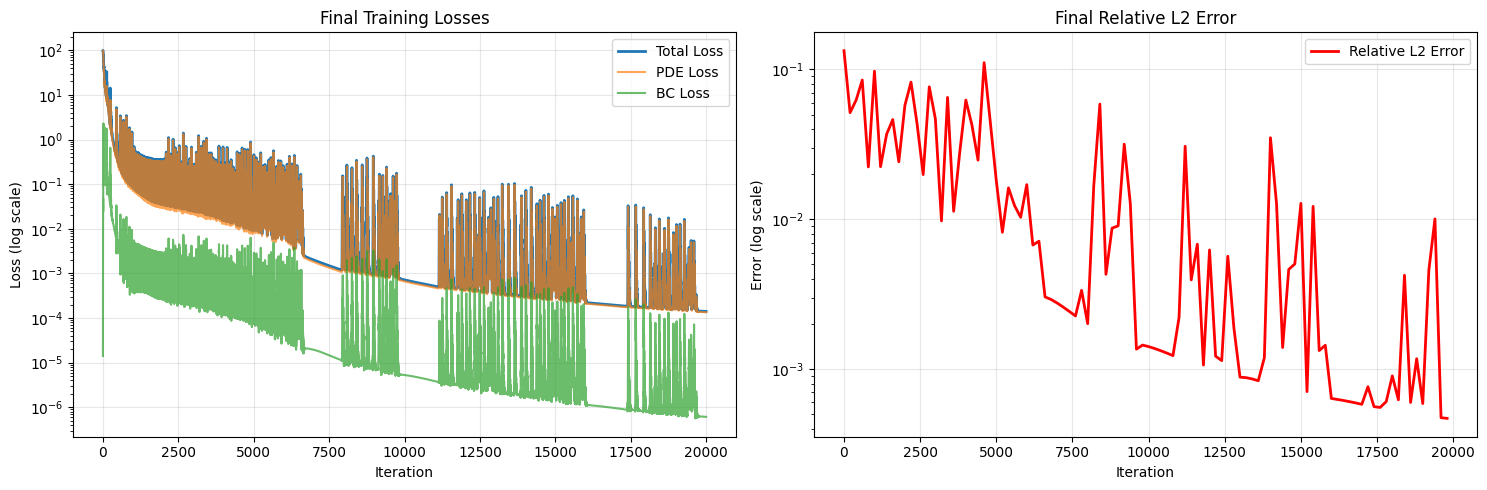

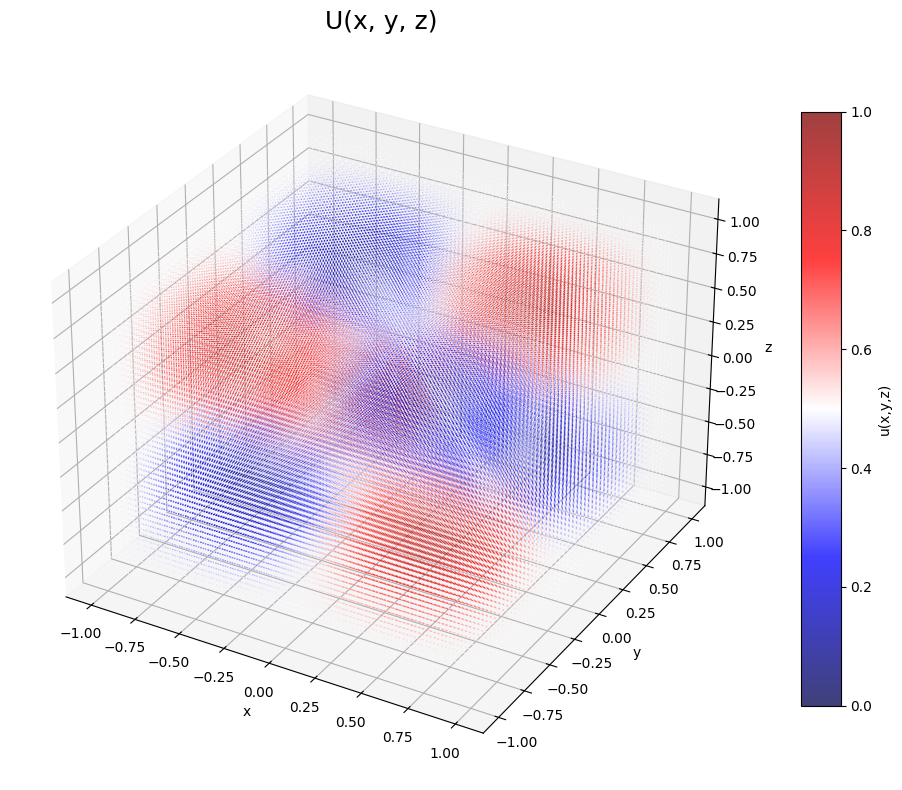

In [11]:
history, best_error, best_u = train_spinn(
    model=model,
    optimizer=optimizer,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs=EPOCHS,
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    N_per_axis=N_PER_AXIS,
    domain_size=1.0,
    device=device,
    scheduler=scheduler,
    pde_weight=1,
    bc_weight=10,
)

После обучения посчитайте итоговые метрики на тестовой сетке.

> Подбирайте качество за счёт корректной архитектуры, выбора гиперпараметров и настройки обучения, не используя прямую подгонку под тестовую сетку. За такое бан.

In [12]:
model.eval()
with torch.no_grad():
    u_pred_final = model(xx_test[:, 0, 0], yy_test[0, :, 0], zz_test[0, 0, :])

mse = ((u_test.cpu().numpy() - u_pred_final.cpu().numpy()) ** 2).mean()
rel_l2 = relative_l2(u_pred_final, u_test).item()

print(f"MSE: {mse:.2e}")
print(f"Relative L2: {rel_l2:.2e}")

MSE: 2.59e-08
Relative L2: 4.69e-04


In [13]:
score_1_2 = 0.0
if mse <= 5e-3:
    score_1_2 = 0.5 * 1.5
if mse <= 5e-4:
    score_1_2 = 0.6 * 1.5
if mse <= 1e-5:
    score_1_2 = 0.7 * 1.5
if mse <= 1e-7:
    score_1_2 = 0.9 * 1.5
if mse <= 5e-8:
    score_1_2 = 1.0 * 1.5

print(f"Баллы за пункт 1.2: {score_1_2:.2f} / 1.5")

Баллы за пункт 1.2: 1.50 / 1.5


Оценка за пункт 1.2 зависит от наилучшего достигнутого порога по `mse`: каждому порогу соответствует своя доля из **1,5 балла** за качество. Итоговый балл определяется по самому строгому из выполненных условий.

> **Примечание.** Итоговые пороги качества для этой части будут проверяться по метрикам на тестовой сетке. Не забывайте сохранить веса лучшей модели: они понадобятся при сдаче домашнего задания.

In [14]:
torch.save(model.state_dict(), "best_spinn_model.pth")

### Задание 1.3. Краткий анализ (0,5 балла)

После обучения кратко опишите, как вы подбирали конфигурацию модели и что наблюдали в экспериментах.

Можно обсудить:

1. С каких параметров вы начали и к какой конфигурации пришли в итоге.
2. Как изменение `rank` влияло на качество и время обучения.
3. Что сильнее влияло на результат: архитектура body-сетей, плотность коллокационной решётки или баланс между `PDE loss` и `BC loss`.
4. Были ли признаки того, что модель реализована некорректно или обучается неустойчиво, и как вы это диагностировали.

`Анализ: 
1. я начинал с ```lr = 5e-4, epochs = 10000``` и поставил scheduler как в 8 семинаре, т.е. ```scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)```, закончил с ```lr = 5e-4, epochs = 20000, pde_weight=1,
    bc_weight=10, scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=300,
    min_lr=1e-6,
)```,
2. я изначально ставил ```rank = 30```, по слухам люди выбивали нужный скор с ```rank=8```
3. Я изначально ставил коэффициент BC больше по опыту обучения пиннов, коллокационную решетку я не изменял. Я уверен, что BC и архитектура(кол-во нейронов и слоев) больше всего влияет
4. когда я ставил первый ```scheduler```, то модель затухала на +-1000 итерациях. Также по опыту обучения пиннов я ставил количество эпох >15000

## Часть 2. Классификация звуков UrbanSound8K с помощью CNN (6 баллов)


### Разбалловка

Во второй части нужно пройти весь стандартный пайплайн аудиоклассификации: подготовить данные, реализовать модель, обучить её и провести итоговую оценку.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 2.1 Подготовка данных и Dataset | **1,0** | Корректный fold-aware pipeline, реализация `UrbanSoundDataset`, аккуратная работа с метками |
| 2.2 Архитектура CNN | **1,0** | Рабочая сверточная модель для классификации мел-спектрограмм |
| 2.3 Обучение и валидация | **1,0** | Реализация train/validate, early stopping, осмысленная настройка обучения |
| 2.4 Качество модели | **2,5** | Итоговое качество по accuracy |
| 2.5 Краткий анализ | **0,5** | Наблюдения по архитектуре, аугментациям, ошибкам модели и качеству |

> В этой части важно не только получить хороший score, но и корректно организовать эксперимент. Использование правильного протокола разбиения данных здесь является частью задания, а не технической деталью.

### Введение в обработку аудио

#### Почему не всегда удобно работать с сырым аудиосигналом?

Аудиосигнал - это последовательность амплитудных отсчётов во времени. Например, 4-секундный фрагмент при частоте дискретизации 22 050 Гц содержит около 88 тысяч значений. Теоретически такие данные можно подавать напрямую в нейросеть, но на практике это не самый удобный вариант:

1. **Высокая размерность.** Даже короткий сигнал содержит много отсчётов.
2. **Сложная временная структура.** В сигнале одновременно важны и короткие локальные паттерны, и более длинные зависимости.
3. **Частотная информация скрыта неявно.** По самому временному ряду не так удобно понять, какие частоты присутствуют в сигнале.

**Спектрограммы**

Это представление сигнала в плоскости "время–частота". Она строится с помощью кратковременного преобразования Фурье (STFT): сигнал разбивается на короткие окна, для каждого окна вычисляется частотный спектр, после чего эти спектры собираются по времени.

В результате получается 2D-представление, где:
- по оси X идёт время;
- по оси Y - частота;
- цвет отражает энергию сигнала на данной частоте в данный момент.

**Мел-спектрограмма**

Обычная спектрограмма полезна, но не полностью соответствует тому, как человек воспринимает звук. Поэтому в задачах аудиоклассификации часто используют мел-спектрограммы.

Идея здесь в том, что:
- частоты переводятся в мел-шкалу, которая лучше соответствует человеческому слуху;
- амплитуды обычно переводятся в децибельную шкалу, то есть в логарифмический масштаб.

Мел-спектрограммы удобны по нескольким причинам:
1. уменьшают размерность;
2. сохраняют наиболее важную перцептивную информацию;
3. дают 2D-представление, с которым удобно работать при помощи CNN.

Именно поэтому в этой части домашнего задания мы будем классифицировать не сырые аудиосигналы, а именно - мел-спектрограммы.

![Пример мел-спектрограммы](https://manual.audacityteam.org/m/images/e/ed/mel_log_linear_spectrogram_annotated.png)

*Пример мел-спектрограммы: ось X - время, ось Y - частота по мел-шкале, цвет отражает амплитуду (от тёмных = низкая энергия до ярких = высокая энергия)*

Источники - [курс DLA](https://github.com/markovka17/dla), [audacity](https://manual.audacityteam.org/man/spectrogram_view.html)

### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

Скачиваем UrbanSound8K отсюда https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Важное замечание про протокол разбиения**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`;
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  
При этом `shuffle=True` внутри `train_loader` использовать можно.

In [3]:
DATASET_PATH = "/kaggle/input/datasets/ommishra03/urbansound8k/UrbanSound8K"

# Загрузим метаданные
metadata = pd.read_csv(os.path.join(DATASET_PATH, "metadata", "UrbanSound8K.csv"))

print(f"Всего примеров: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata["class"].value_counts().sort_index())
print("\nРаспределение по fold'ам:")
print(metadata["fold"].value_counts().sort_index())

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Распределение по fold'ам:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

Sample: 166931-4-3-2.wav
Class: drilling
Fold: 6



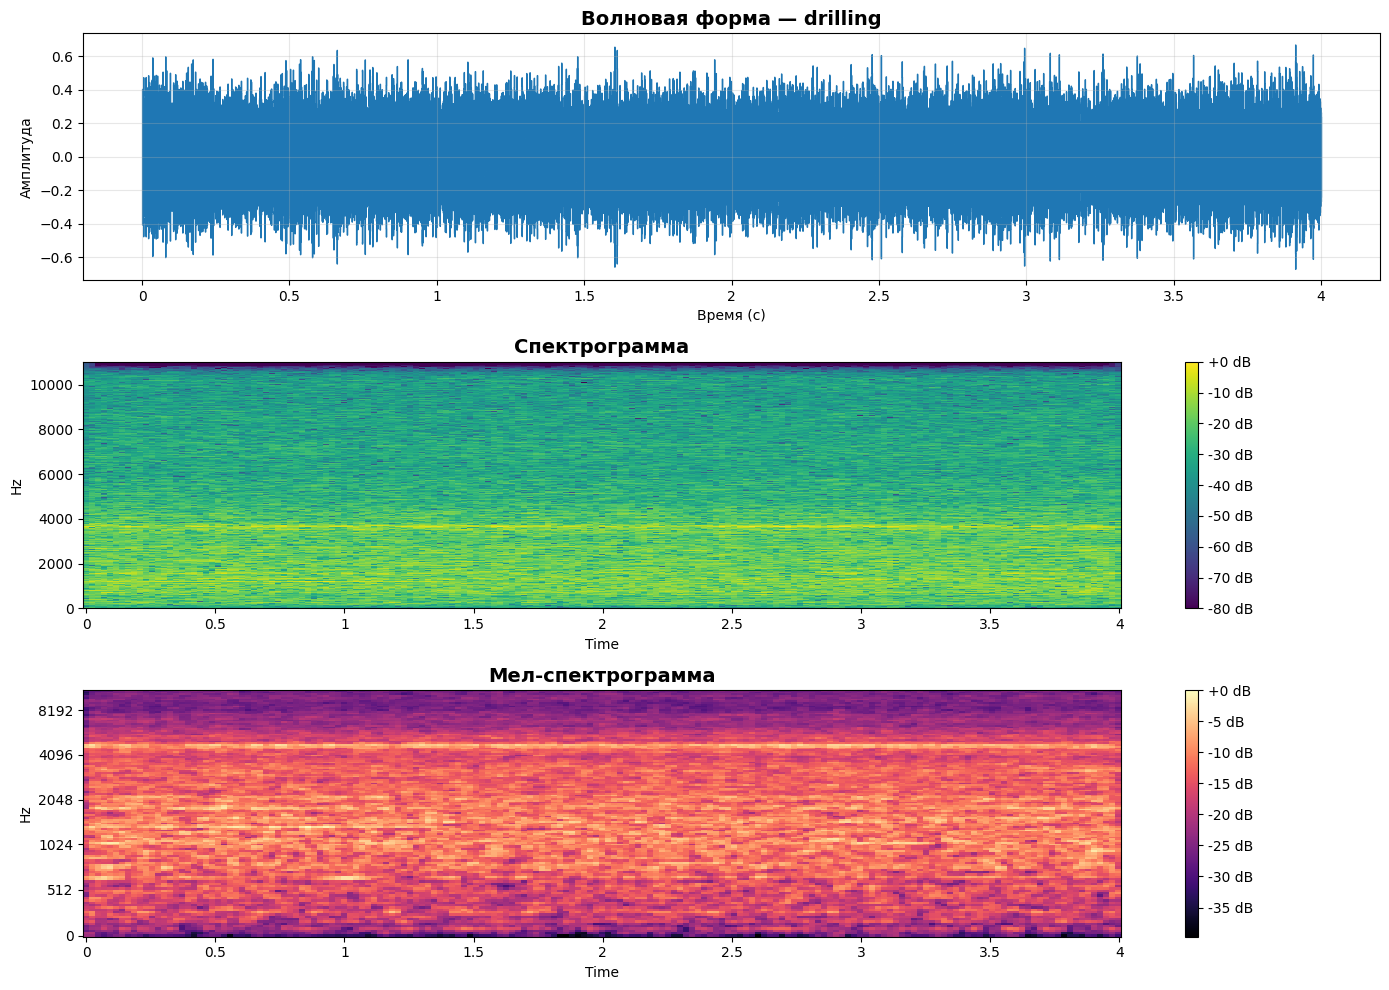

In [5]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis"
    )
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma"
    )
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr


random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, "audio", f"fold{sample.fold}", sample.slice_file_name)
print(f"Sample: {sample.slice_file_name}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample.fold}\n")

y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
Audio(y, rate=sr)

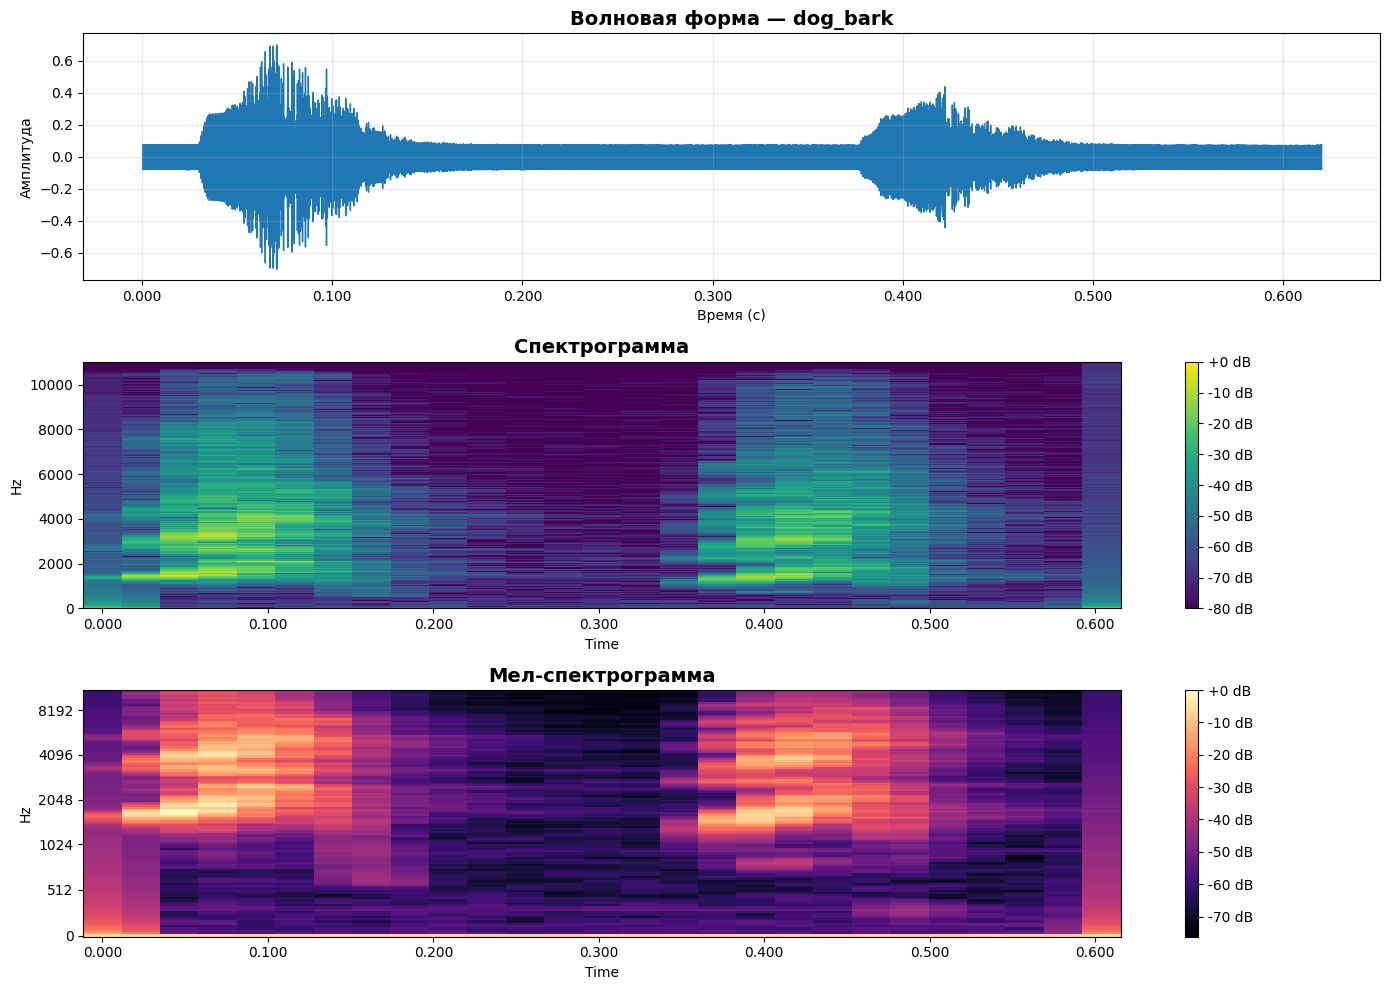

In [6]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH, 'audio', f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

### Задание 2.1. Подготовьте датасет к обучению модели (1 балл)

В этой части нужно реализовать `UrbanSoundDataset`.

Несколько важных условий:

- используйте официальные fold'ы;
- не делайте `fit` для `LabelEncoder` отдельно на каждом split;
- не извлекайте мел-спектрограммы заново при каждом обращении к `__getitem__`, если этого можно избежать.

**Последний пункт особенно важен.** Извлечение спектрограмм через `librosa` - CPU-bound операция, и если делать её на лету для каждого батча, обучение быстро начинает тормозить не из-за модели, а из-за препроцессинга. Поэтому в этой задаче рекомендуется один раз подготовить спектрограммы и либо держать их в памяти, либо кэшировать на диск.

Идея простая: `__getitem__` должен быть как можно легче. В идеале там уже не должно происходить ничего дорогого, кроме извлечения готового тензора и, при необходимости, несложной аугментации.

In [4]:
# Единый LabelEncoder

ALL_CLASSES = sorted(metadata["class"].unique())
global_label_encoder = LabelEncoder()
global_label_encoder.fit(ALL_CLASSES)

print(f"Классы ({len(global_label_encoder.classes_)}):")
print(list(global_label_encoder.classes_))

Классы (10):
[np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


In [17]:
class UrbanSoundDataset(Dataset):
    def __init__(
        self,
        metadata,
        dataset_path,
        label_encoder,
        target_length=4,
        sr=22050,
        n_mels=128,
        augment=False,
        cache_dir=None,
    ):
        """
        Реализуйте датасет для UrbanSound8K.

        Что стоит продумать:
        - как хранить metadata и переиндексировать его
        - как загружать аудио и приводить его к фиксированной длине
        - как строить и нормализовать мел-спектрограммы
        - как организовать кэш, чтобы не пересчитывать спектрограммы каждый раз
        - какие аугментации допустимо применять только на train
        """

        self.metadata = metadata.reset_index(drop=True)
        self.dataset_path = dataset_path
        self.label_encoder = label_encoder
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment
        self.target_samples = int(target_length * sr)
        
        self.spec_cache = {}
        
        self.prec_spectrs()
    
    def prec_spectrs(self):
        all_specs = []
        
        for i in range(len(self.metadata)):
            row = self.metadata.iloc[i]
            file_path = os.path.join(
                self.dataset_path,
                "audio",
                f"fold{row['fold']}",
                row['slice_file_name']
            )
            
            y = self.load_audio(file_path)
            mel_spec = self.extract_mel_spectrogram(y)
            self.spec_cache[i] = mel_spec
            all_specs.append(mel_spec)
        
        all_specs = np.concatenate(all_specs, axis=1)
        self.mean = np.mean(all_specs)
        self.std = np.std(all_specs)

    def __len__(self):
        return len(self.metadata)

    def load_audio(self, file_path):
        """
        Загрузить аудио, привести к нужной частоте дискретизации
        и длине target_length
        """
        y, _ = librosa.load(file_path, sr=self.sr, mono=True)
        
        if len(y) < self.target_samples:
            y = np.pad(y, (0, self.target_samples - len(y)), mode='constant')
        else:
            y = y[:self.target_samples]
        
        return y

    def extract_mel_spectrogram(self, y):
        """
        Построить мел-спектрограмму и перевести её в dB-шкалу
        """
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=2048,
            hop_length=512
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        return mel_spec_db

    def augment_mel(self, y):
        augmented = y.copy()
        
        if np.random.rand() < 0.5:
            noise_std = 0.01 * (np.std(augmented) + 1e-8)
            noise = np.random.randn(*augmented.shape) * noise_std
            augmented = augmented + noise
        
        if np.random.rand() < 0.5:
            volume_factor = np.random.uniform(0.7, 1.3)
            augmented = augmented * volume_factor

        if np.random.rand() < 0.5:
            max_shift = int(0.2 * augmented.shape[1])
            shift = np.random.randint(-max_shift, max_shift + 1)
            if shift != 0:
                augmented = np.roll(augmented, shift, axis=1)
                if shift > 0:
                    augmented[:, :shift] = 0
                else:
                    augmented[:, shift:] = 0
        
        return augmented

    def __getitem__(self, idx):
        """
        Вернуть пару (mel_spectrogram, label)
        """
        row = self.metadata.iloc[idx]
        mel_spec = self.spec_cache[idx]

        if self.augment:
            mel_spec = self.augment_mel(mel_spec)
        mel_spec = (mel_spec - self.mean) / (self.std + 1e-8)
        
        mel_spec = torch.FloatTensor(mel_spec).unsqueeze(0)
        label = self.label_encoder.transform([row['class']])[0]
        label = torch.LongTensor([label]).squeeze()
        
        return mel_spec, label

In [6]:
def get_fold_split(metadata, test_fold, val_fold=None):
    """
    Разбиение по official folds.

    Если val_fold задан:
        train = все fold'ы, кроме test_fold и val_fold
        val   = val_fold
        test  = test_fold

    Если val_fold не задан:
        train = все fold'ы, кроме test_fold
        test  = test_fold
    """
    test_df = metadata[metadata["fold"] == test_fold]

    if val_fold is not None:
        assert val_fold != test_fold
        val_df = metadata[metadata["fold"] == val_fold]
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]
    else:
        val_df = None
        train_folds = [f for f in range(1, 11) if f != test_fold]

    train_df = metadata[metadata["fold"].isin(train_folds)]

    print(
        f"test={test_fold}"
        + (f", val={val_fold}" if val_fold is not None else "")
        + f" | Train: {len(train_df)}, Val: {len(val_df) if val_df is not None else 0}, Test: {len(test_df)}"
    )
    return train_df, val_df, test_df

#### Dev-split для быстрых экспериментов

Для подбора архитектуры и отладки удобно сначала работать на одном фиксированном разбиении:
- `train = folds 1–8`
- `val = fold 9`
- `test = fold 10`

Финальную 10-fold оценку лучше запускать уже после того, как основная конфигурация выбрана.

In [18]:
train_df, val_df, test_df = get_fold_split(metadata, test_fold=10, val_fold=9)

BATCH_SIZE = 64

train_dataset = UrbanSoundDataset(
    train_df,
    DATASET_PATH,
    global_label_encoder,
    augment=True,
    cache_dir = ""
)

val_dataset = UrbanSoundDataset(
    val_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

test_dataset = UrbanSoundDataset(
    test_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"First labels: {sample_labels[:5]}")

test=10, val=9 | Train: 7079, Val: 816, Test: 837
Batch shape: torch.Size([64, 1, 128, 173])
Labels shape: torch.Size([64])
First labels: tensor([0, 4, 3, 4, 7])


### Задание 2.2. Реализуйте вашу архитектуру (1 балл)

В этой задаче разрешены только **свёрточные архитектуры**.

Нельзя использовать:
- RNN;
- LSTM / GRU;
- Transformer.

Можно использовать: обычные CNN-блоки, batch normalization, dropout,pooling, при желании - несложные attention-модули поверх CNN, если основа модели всё равно остаётся сверточной.

На вход модель получает мел-спектрограмму формы `(B, 1, n_mels, time)`, а на выходе должна возвращать логиты по 10 классам.

In [22]:
import torch.nn.functional as F

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        reduced = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.27):
        super().__init__()
        self.maincut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            SEBlock(out_ch),
            nn.Dropout(dropout)
        )

        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.maincut(x)
        out += self.shortcut(x)
        return F.relu(out)


class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=10, base=32, dropout=0.3, use_specaugment=True):
        super().__init__()

        self.prep = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.main = nn.Sequential(
            ResBlock(32, 64, stride=1),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=2),
            ResBlock(128, 192, stride=2)
        )
        self.clasif = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(192, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.prep(x)
        x = self.main(x)
        return self.clasif(x)

### Задание 2.3. Реализуйте обучение и валидацию модели (1 балл)

Теперь нужно написать код обучения модели на dev-split.

Ожидается, что у вас будут:
- функция `train_epoch`;
- функция `validate`;
- цикл обучения с early stopping;
- сохранение лучшей модели по качеству на валидации.

Здесь нет единственно правильной реализации, но ваш код должен быть аккуратным, воспроизводимым и согласованным с поставленной задачей.

In [23]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss = 0.0
    acc = 0
    cnt = 0

    for inputs, y in tqdm(loader, desc="Training"):
        inputs, y = inputs.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(inputs)
        cur = criterion(y_pred, y)
        cur.backward()
        optimizer.step()

        loss += cur.item() * inputs.size(0)
        cnt += inputs.size(0)
        _, pred = y_pred.max(1)
        acc += pred.eq(y).sum().item()

    return loss / cnt, acc / cnt
    
def validate(model, loader, criterion, device):
    model.eval()
    loss = 0.0
    acc = 0
    cnt = 0
    with torch.no_grad():
        for inputs, y in tqdm(loader, desc="Validate"):
            inputs, y = inputs.to(device), y.to(device)
    
            y_pred = model(inputs)
            cur = criterion(y_pred, y)
    
            loss += cur.item() * inputs.size(0)
            cnt += inputs.size(0)
            _, pred = y_pred.max(1)
            acc += pred.eq(y).sum().item()

    return loss / cnt, acc / cnt

model = UrbanSoundCNN(num_classes=10).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nModel:")
print(model)

Total parameters: 1,201,706
Trainable parameters: 1,201,706

Model:
UrbanSoundCNN(
  (prep): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (main): Sequential(
    (0): ResBlock(
      (maincut): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SEBlock(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (fc): Sequential(
            (0): Linear(in_features=64, out_features=

In [24]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 50
PATIENCE = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_cnn_model.pth")
        patience_counter = 0
        print("Saved best model")
    print("-" * 30)

print(f"End. Best val: {best_val_acc:.4f}")

Epoch 1/50


Training:   0%|          | 0/111 [00:00<?, ?it/s]

Validate:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 1.6691 | Train Acc: 0.4595
Val Loss: 1.5206 | Val Acc: 0.5429
Saved best model
------------------------------
Epoch 2/50


Training:   0%|          | 0/111 [00:00<?, ?it/s]

...

Validate:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.5382 | Train Acc: 0.9948
Val Loss: 1.1745 | Val Acc: 0.7684
------------------------------
Epoch 50/50


Training:   0%|          | 0/111 [00:00<?, ?it/s]

Validate:   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.5376 | Train Acc: 0.9936
Val Loss: 1.1488 | Val Acc: 0.7708
------------------------------
End. Best val: 0.7843


После обучения оцените модель на test-части dev-split. Затем постройте confusion matrix и посмотрите, какие классы модель путает чаще всего.

In [25]:
model.load_state_dict(torch.load("best_cnn_model.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy on dev-split: {test_acc * 100:.2f}%")

Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Test accuracy on dev-split: 79.93%


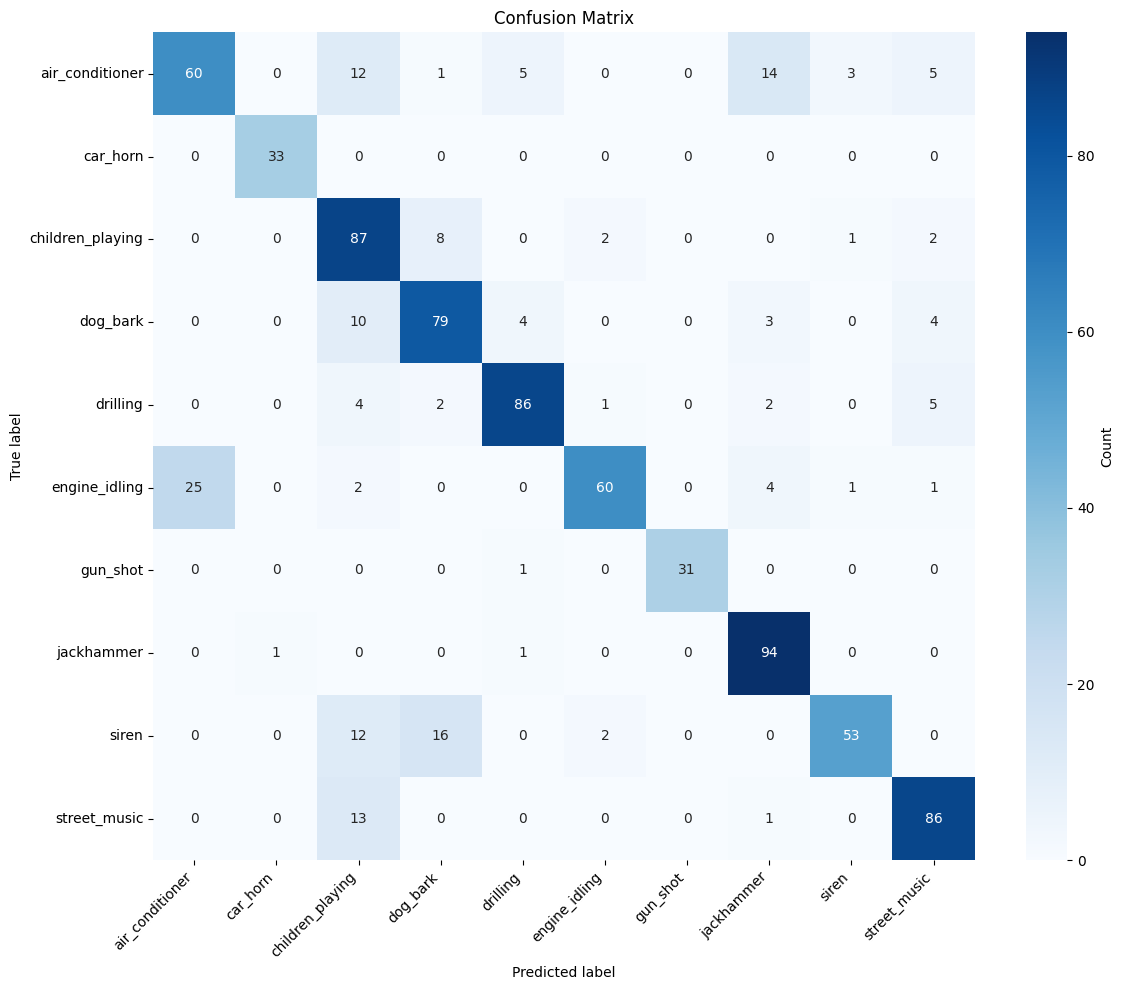

                  precision    recall  f1-score   support

 air_conditioner     0.7059    0.6000    0.6486       100
        car_horn     0.9706    1.0000    0.9851        33
children_playing     0.6214    0.8700    0.7250       100
        dog_bark     0.7453    0.7900    0.7670       100
        drilling     0.8866    0.8600    0.8731       100
   engine_idling     0.9231    0.6452    0.7595        93
        gun_shot     1.0000    0.9688    0.9841        32
      jackhammer     0.7966    0.9792    0.8785        96
           siren     0.9138    0.6386    0.7518        83
    street_music     0.8350    0.8600    0.8473       100

        accuracy                         0.7993       837
       macro avg     0.8398    0.8212    0.8220       837
    weighted avg     0.8143    0.7993    0.7975       837



In [26]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = global_label_encoder.classes_

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

### Задание 2.4. Финальная 10-fold оценка (2,5 балла)

После того как вы подобрали рабочую конфигурацию на dev-split, проведите один финальный прогон 10-fold cross-validation.

Для каждого `test_fold`:
- `val_fold` берётся как следующий fold по кругу;
- все остальные fold'ы идут в train.

Итоговое качество считается по средней accuracy по всем 10 fold'ам.

In [36]:
def evaluate_10fold(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    dataset_path,
    label_encoder,
    device="cuda",
    verbose=True,
):
    """
    10-fold CV по folds UrbanSound8K
    """
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = UrbanSoundDataset(train_df, dataset_path, label_encoder, augment=True)
        val_ds = UrbanSoundDataset(val_df, dataset_path, label_encoder, augment=False)
        test_ds = UrbanSoundDataset(test_df, dataset_path, label_encoder, augment=False)

        loader_kwargs = dict(num_workers=0, pin_memory=True)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kwargs)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, **loader_kwargs)

        model = model_class(**model_kwargs).to(device)
        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

In [37]:
import copy

def my_train_fn(model, train_loader, val_loader, device):
    """
    Оберните свой training loop в функцию.
    Она должна вернуть обученную модель.
    """

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr = 1e-6)
    best_model_wts = copy.deepcopy(model.state_dict())
    
    NUM_EPOCHS = 50
    PATIENCE = 15
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }
    
    best_val_acc = 0.0
    patience_counter = 0
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
    
        scheduler.step(val_loss)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
    
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (patience_counter >= PATIENCE):
            break
    
    model.load_state_dict(best_model_wts)
    return model

In [38]:
accuracies = evaluate_10fold(
    model_class=UrbanSoundCNN,
    model_kwargs={"num_classes": 10},
    train_fn=my_train_fn,
    metadata=metadata,
    dataset_path=DATASET_PATH,
    label_encoder=global_label_encoder,
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])


Training:   0%|          | 0/109 [00:00<?, ?it/s]

Validate:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/109 [00:00<?, ?it/s]

Validate:   0%|          | 0/14 [00:00<?, ?it/s]

...

Training:   0%|          | 0/110 [00:00<?, ?it/s]

Validate:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/110 [00:00<?, ?it/s]

Validate:   0%|          | 0/14 [00:00<?, ?it/s]

Fold 10 accuracy: 77.18%

10-fold CV: 70.79% ± 4.30%


In [39]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

for i, acc in enumerate(accuracies, 1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print(f"\n10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

Fold 1: 67.24%
Fold 2: 71.40%
Fold 3: 64.00%
Fold 4: 70.51%
Fold 5: 72.86%
Fold 6: 65.01%
Fold 7: 77.57%
Fold 8: 70.22%
Fold 9: 71.94%
Fold 10: 77.18%

10-fold CV: 70.79% ± 4.30%


Баллы за пункт 2.4 начисляются в зависимости от лучшего выполненного порога по средней accuracy в 10-fold CV: чем выше итоговое качество, тем больше доля из 2,5 балла за эту часть.

In [40]:
score_2_4 = 0.0

if mean_acc >= 0.64:
    score_2_4 = 0.5 * 2.5
if mean_acc >= 0.69:
    score_2_4 = 0.6 * 2.5
if mean_acc >= 0.74:
    score_2_4 = 0.7 * 2.5
if mean_acc >= 0.79:
    score_2_4 = 0.8 * 2.5
if mean_acc >= 0.84:
    score_2_4 = 0.9 * 2.5
if mean_acc >= 0.88:
    score_2_4 = 1.0 * 2.5

print(f"Mean CV accuracy: {mean_acc:.4f}")
print(f"Баллы за пункт 2.4: {score_2_4:.2f} / 2.5")

Mean CV accuracy: 0.7079
Баллы за пункт 2.4: 1.50 / 2.5


### Задание 2.5. Краткий анализ (0,5 балла)

В конце прокомментируйте свою работу:

1. Какую архитектуру вы выбрали и почему.
2. Какие аугментации оказались полезными, а какие нет.
3. Что сильнее влияло на качество: сама CNN, preprocessing или параметры обучения.
4. Какие классы модель путала чаще всего и почему это выглядит правдоподобно.
5. Насколько различались результаты между fold'ами.


```
Анализ: 
1. residual network, потому что много слоев и чтобы градиент не затухал
2. аугментации по удалению промежутков частот и времени не очень помогли, а добавление шума помогло
3. По большей части влияет архитектура, у меня была модель на 2.5e6 параметров и выбивала скор на валидации 0.83, но тестилась долго и я не решался ее тестить на 10fold(хотя надо было бы). Потом preprocessing, когда было меньше аугментации, мне казалось качество было лучше. Параметры обучения особо не меняли, а scheduler на CosineAnnealingWarmRestarts делал еще хуже
4. engine_idling -> air_conditioner - потому что стабильный звук. siren -> dog_bark - потому что высокочастотные, air_conditioner, street_music -> children_playing - фоновый звук людей
5. по большей части рандом, но в ближе к концу повыше
```

### Рефлексия

С помощью Gemini Pro 3.1 мне помог написать UrbanSoundDataset, в основном предложил идеи для аугментации.

Так как я не успеваю, то мне нужна была модель, которая не очень большая по размеру и имеет достаточный accuracy. После добавления SEBlock, модель прибавила на 1-2%.

Еще за меня Gemini сделал sanity check в SPinn